In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

In [ ]:
data=pd.concat([y,X],axis=1)
data['income'] = data['income'].str.replace('.', '', regex=False)
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,<=50K,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,<=50K,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,<=50K,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,<=50K,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,<=50K,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
data.dropna(inplace=True)
data.shape

(47621, 15)

In [ ]:
data = data.sample(n=10000, random_state=42)

data['education'] = data['education'].replace(['11th', '10th', '9th', '12th'], 'HS-no_grad')
data['education'] = data['education'].replace(['Preschool','1st-4th', '5th-6th', '7th-8th'], 'Grade_school')
data['workclass'] = data['workclass'].replace(['Local-gov', 'State-gov', 'Federal-gov'], 'Gov-jobs')
data['workclass'] = data['workclass'].replace(['Self-emp-not-inc', 'Self-emp-inc'], 'Self-employed')
data['marital-status']=data['marital-status'].replace(['Divorced', 'Separated'], 'No-longer-married')
data = data.replace('?', 'Undisclosed')
data['native-country'] = data['native-country'].apply(lambda x: x if x in ['United-States', 'Mexico'] else 'other cont')
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1536,<=50K,34,Private,122116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
20190,<=50K,36,Gov-jobs,223020,Some-college,10,No-longer-married,Other-service,Unmarried,Black,Female,0,0,20,United-States
47437,<=50K,59,Self-employed,165867,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,25,United-States
10192,>50K,59,Private,453067,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,36,United-States
38494,>50K,36,Private,49657,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States


In [ ]:
data['native-country'].value_counts()

,count
native-country,
United-States,9050
other cont,748
Mexico,202


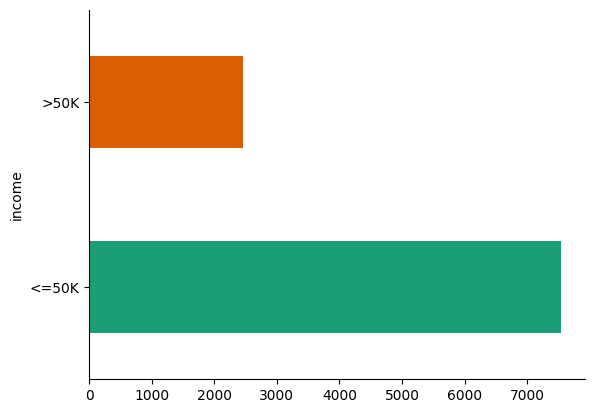

In [ ]:
# @title income

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('income').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1536 to 7605
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   income          10000 non-null  object
 1   age             10000 non-null  int64 
 2   workclass       10000 non-null  object
 3   fnlwgt          10000 non-null  int64 
 4   education       10000 non-null  object
 5   education-num   10000 non-null  int64 
 6   marital-status  10000 non-null  object
 7   occupation      10000 non-null  object
 8   relationship    10000 non-null  object
 9   race            10000 non-null  object
 10  sex             10000 non-null  object
 11  capital-gain    10000 non-null  int64 
 12  capital-loss    10000 non-null  int64 
 13  hours-per-week  10000 non-null  int64 
 14  native-country  10000 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.2+ MB


In [ ]:
data.shape

(10000, 15)

In [ ]:
obj_data=data.loc[:,['sex','workclass','education','marital-status','occupation','relationship','race','native-country']]
data.drop(columns=['sex','workclass','education','marital-status','occupation','relationship','race','native-country'],inplace=True)

obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})

encoder = LabelEncoder()
for col in data.select_dtypes("object"):
    data[col] =encoder.fit_transform(data[[col]])

X=data.drop(columns=['income'])
X=pd.concat([X,obj_data],axis=1)
X = X.astype(float)
y=data['income']
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_United-States,fet_other cont
1536,34.0,122116.0,10.0,0.0,0.0,40.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
20190,36.0,223020.0,10.0,0.0,0.0,20.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
47437,59.0,165867.0,13.0,0.0,0.0,25.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10192,59.0,453067.0,10.0,0.0,0.0,36.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
38494,36.0,49657.0,13.0,0.0,0.0,50.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


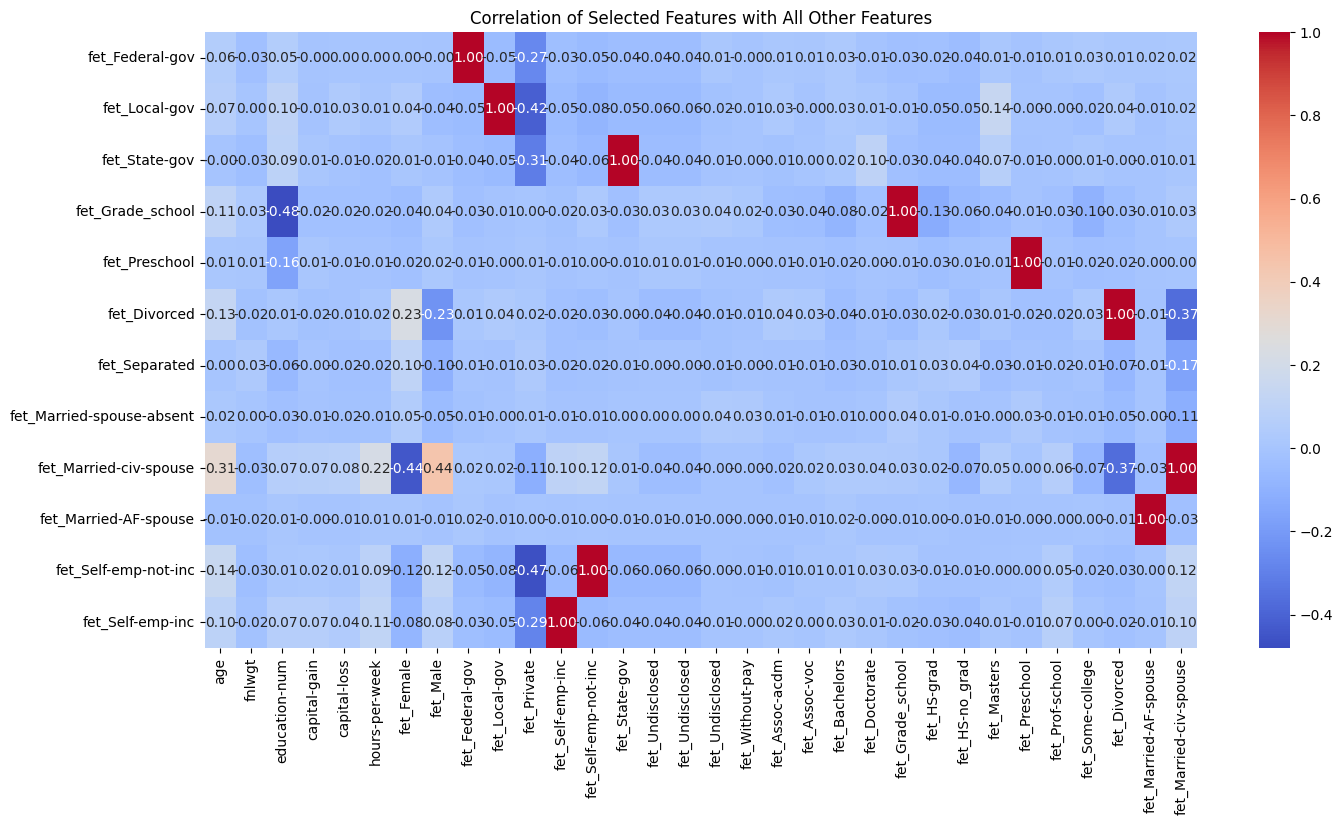

In [ ]:
selected_columns = ['fet_Federal-gov', 'fet_Local-gov', 'fet_State-gov',
                   'fet_Grade_school', 'fet_Preschool', 'fet_Divorced',
                   'fet_Separated', 'fet_Married-spouse-absent','fet_Married-civ-spouse','fet_Married-AF-spouse','fet_Self-emp-not-inc','fet_Self-emp-inc']

# Calculate the correlation matrix for all features in X
correlation_matrix = X.corr()

# Get the first 30 column names of the correlation matrix
columns_to_select = correlation_matrix.columns[:30]

# Extract the correlations for the selected features with the first 30 columns
selected_correlations = correlation_matrix.loc[selected_columns, columns_to_select]

plt.figure(figsize=(16, 8))
sns.heatmap(selected_correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Selected Features with All Other Features')
plt.show()

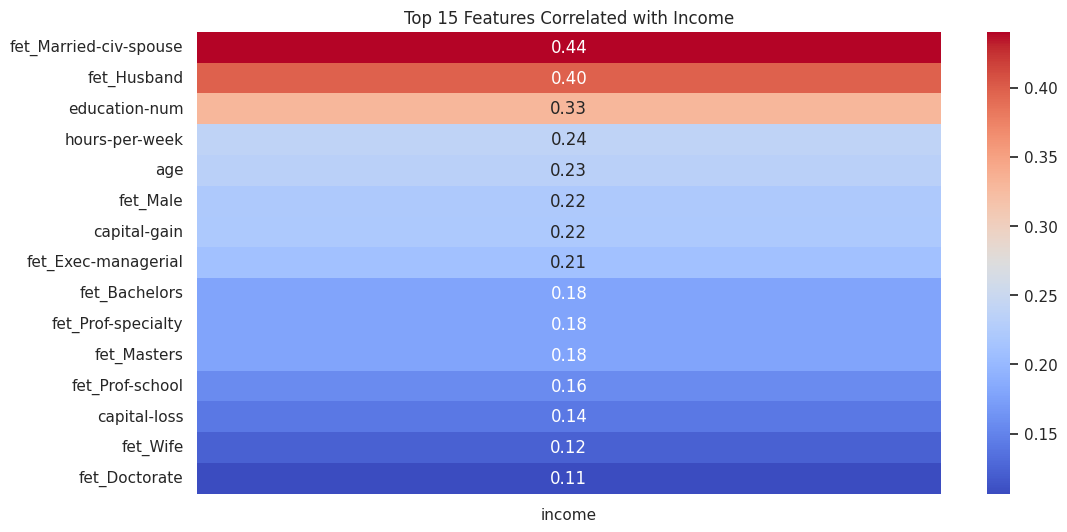

In [ ]:
sns.set(style="darkgrid")
sns.set_palette("pastel")

plt.figure(figsize=(12,6))
data2=pd.concat([y,X],axis=1)

correlations = data2.corr()['income'].sort_values(ascending=False)

# Select top 15 features
top_15_features = correlations[1:16]  # Exclude 'income' itself

top_15_corr_df = pd.DataFrame(top_15_features)
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

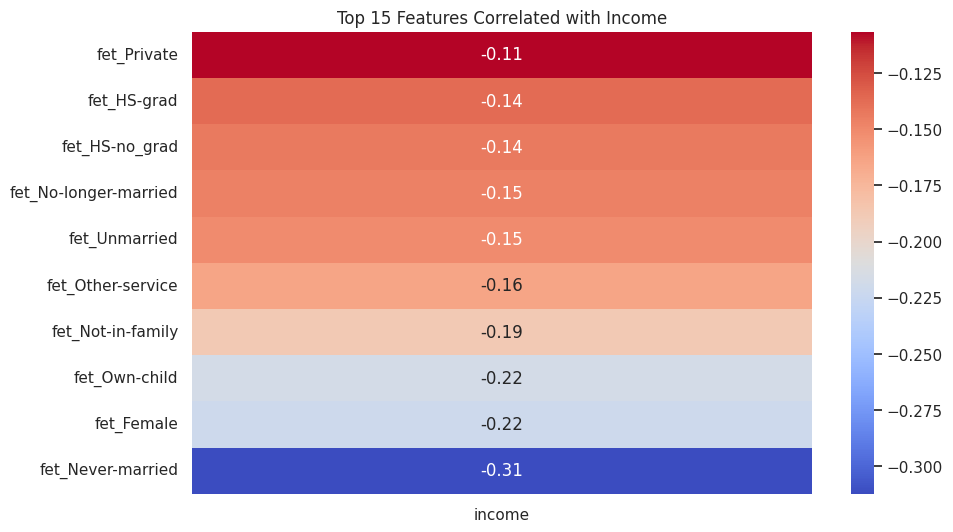

In [ ]:
plt.figure(figsize=(10,6))
top_15_corr_df = pd.DataFrame(correlations[49:59])
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

In [ ]:
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)

X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_United-States,fet_other cont
1536,-0.352676,-0.634431,-0.046688,-0.146619,-0.210876,-0.062394,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,0.323994,-0.284337
20190,-0.204555,0.312651,-0.046688,-0.146619,-0.210876,-1.713240,1.422634,-1.422634,2.505598,-1.541459,...,2.848819,-0.217072,-0.102515,-0.167845,3.124782,-0.086343,-2.498225,-0.143584,0.323994,-0.284337
47437,1.498836,-0.223786,1.120512,-0.146619,-0.210876,-1.300529,-0.702921,0.702921,-0.399106,-1.541459,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,0.323994,-0.284337
10192,1.498836,2.471865,-0.046688,-0.146619,-0.210876,-0.392563,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,0.323994,-0.284337
38494,-0.204555,-1.314529,1.120512,-0.146619,-0.210876,0.763030,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,0.323994,-0.284337


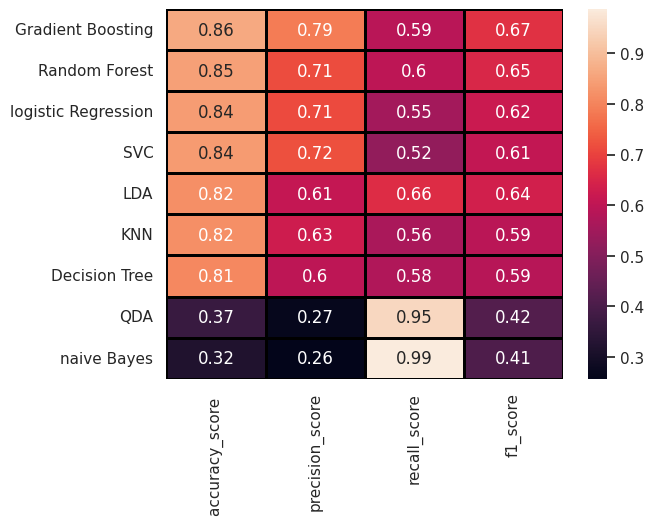

In [ ]:
model_dic={
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'QDA':QDA(),
    "Decision Tree":DTC(criterion='entropy'),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1)
plt.show()

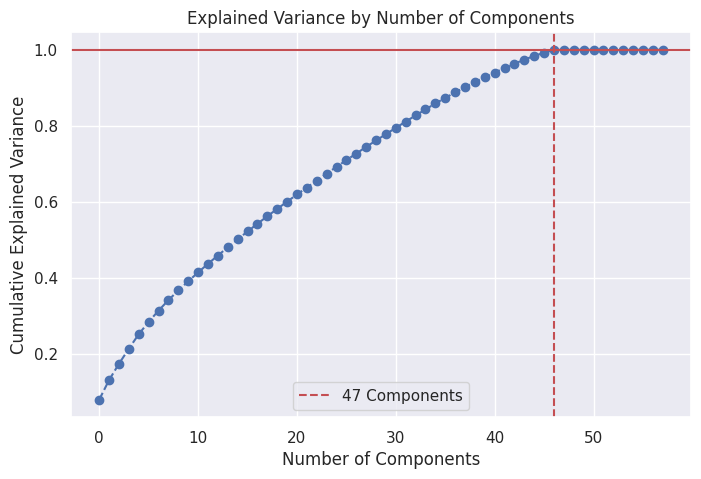

Optimal number of components to retain 99.9% variance: 47


In [ ]:
pca = PCA()
pca.fit(X_train)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
optimal_components = np.argmax(cumulative_variance >= 0.999) + 1  # Threshold: 95%


plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', linestyle='--',color='b')
plt.axhline(y=0.999, color='r', linestyle='-')
plt.axvline(x=optimal_components - 1, color='r', linestyle='--', label=f'{optimal_components} Components')
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

print(f"Optimal number of components to retain 99.9% variance: {optimal_components}")



In [ ]:
pca_optimal = PCA(n_components=optimal_components)
X_train = pca_optimal.fit_transform(X_train)
X_test = pca_optimal.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train, columns=[f'PC{i+1}' for i in range(X_train.shape[1])])
X_test = pd.DataFrame(X_test, columns=[f'PC{i+1}' for i in range(X_test.shape[1])])

In [ ]:
X_train.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47
0,-2.860249,-0.809444,0.410274,0.103064,-0.634214,-0.525627,0.988956,0.496490,-0.371311,0.577974,...,0.939540,-1.148846,-0.898664,-1.025404,1.091719,-1.052995,1.989858,-0.930205,-0.022382,-0.827647
1,2.000034,-0.858215,0.326101,0.727082,-0.797407,0.248730,0.796727,-0.749884,-0.432597,-0.244768,...,1.403674,-0.220058,-0.983512,-0.356118,-0.319381,-0.331760,0.184666,-0.318409,0.854250,0.728337
2,2.277678,-0.143872,0.313691,0.227856,-0.645804,0.026404,0.450767,-0.235210,-1.654756,1.114789,...,-0.145486,0.354845,-0.256648,-0.433535,0.162339,-0.013148,0.228422,-1.225931,2.195866,0.238678
3,-2.827386,-0.434755,1.602825,0.070810,0.102797,-0.168324,1.469747,0.951290,-0.376964,0.960123,...,1.051545,-0.221665,-0.598123,-0.843283,-0.444114,-0.683742,0.741993,-0.558483,0.076833,0.821261
4,-2.845048,-0.153702,-3.036725,-0.438128,-0.946617,-2.540978,0.010387,-0.113917,0.821839,0.059307,...,-1.554781,1.978787,1.866269,-0.298323,-0.862823,0.500406,1.650615,0.008196,-0.342071,-1.839075


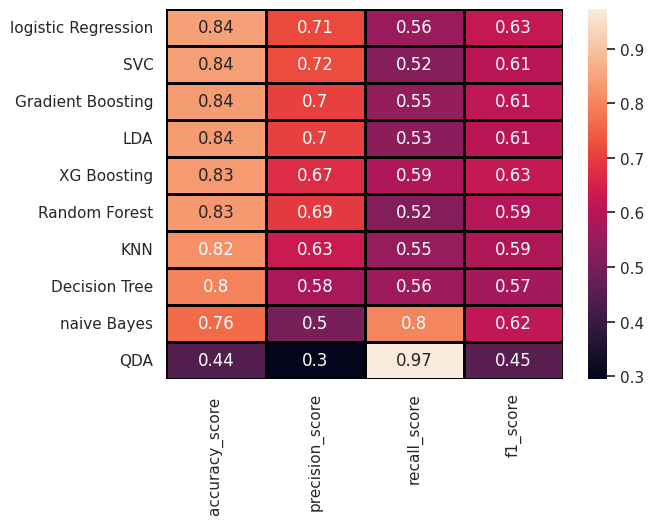

In [ ]:
model_dic={
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    "Decision Tree":DTC(criterion='entropy'),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)  # Convert to numpy array for xGboost
        y_pred = model.predict(X_test.to_numpy())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1)
plt.show()

In [ ]:

# Get the loadings of the first two principal components
loadings = pca_optimal.components_[:2]

feature_names = X.columns

loadings_df = pd.DataFrame(loadings.T, columns=['PC1', 'PC2'], index=feature_names)

# Display the features that make up the first two principal components
print("Features that make up the first two principal components:")
print(loadings_df)

# Get the explained variance ratio for the first two components
explained_variance_ratio = pca_optimal.explained_variance_ratio_[:2]

# Calculate the percentage contribution of the first two components
percentage_contribution = explained_variance_ratio * 100

print("\nPercentage contribution of the first two principal components:")
print(f"PC1: {percentage_contribution[0]:.2f}%")
print(f"PC2: {percentage_contribution[1]:.2f}%")

Features that make up the first two principal components:
                                PC1       PC2
age                        0.172259  0.108718
fnlwgt                    -0.019799 -0.056732
education-num              0.082972  0.463320
capital-gain               0.052240  0.070362
capital-loss               0.058420  0.072024
hours-per-week             0.178766  0.069022
fet_Female                -0.344290  0.181153
fet_Male                   0.344290 -0.181153
fet_Gov-jobs               0.016587  0.218381
fet_Private               -0.103385 -0.211927
fet_Self-employed          0.147098  0.073120
fet_Undisclosed           -0.029851 -0.009687
fet_Without-pay           -0.002992 -0.004177
fet_Assoc-acdm            -0.011476  0.055815
fet_Assoc-voc              0.009824  0.032905
fet_Bachelors              0.055584  0.234339
fet_Doctorate              0.040548  0.122624
fet_Grade_school           0.014531 -0.199942
fet_HS-grad               -0.015564 -0.194940
fet_HS-no_grad        

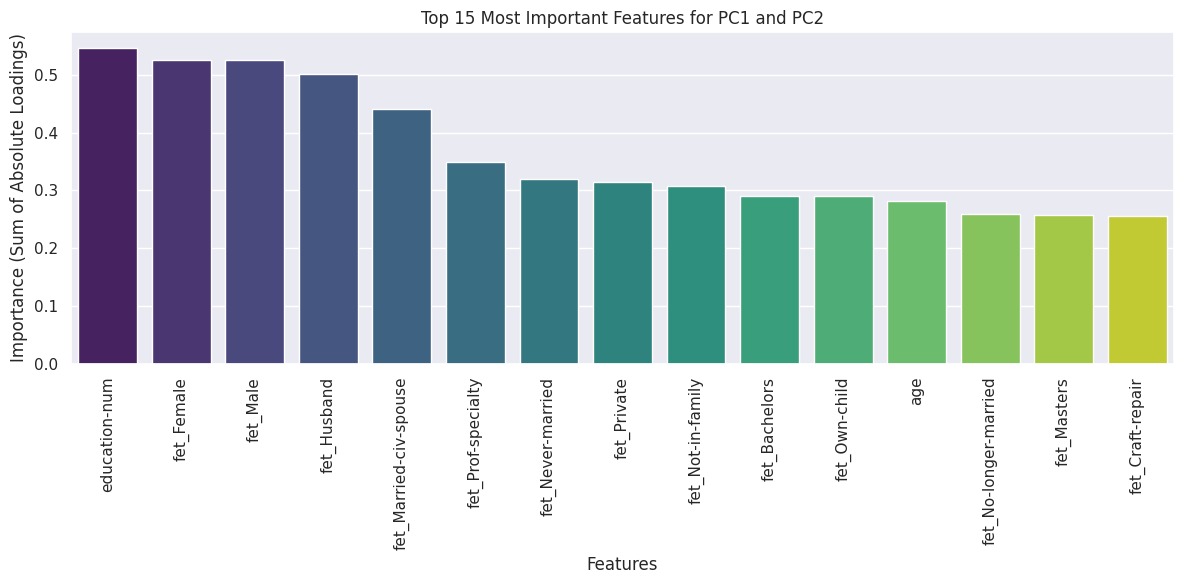

In [ ]:
# Get the absolute values of loadings for PC1 and PC2
loadings_abs = loadings_df[['PC1', 'PC2']].abs()

# Sort features by importance (sum of absolute loadings across PC1 and PC2
sorted_features = loadings_abs.sum(axis=1).sort_values(ascending=False)

# Select the top 15 features
top_15_features = sorted_features[:15]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_15_features.index, y=top_15_features.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance (Sum of Absolute Loadings)')
plt.title('Top 15 Most Important Features for PC1 and PC2')
plt.tight_layout()
plt.show()

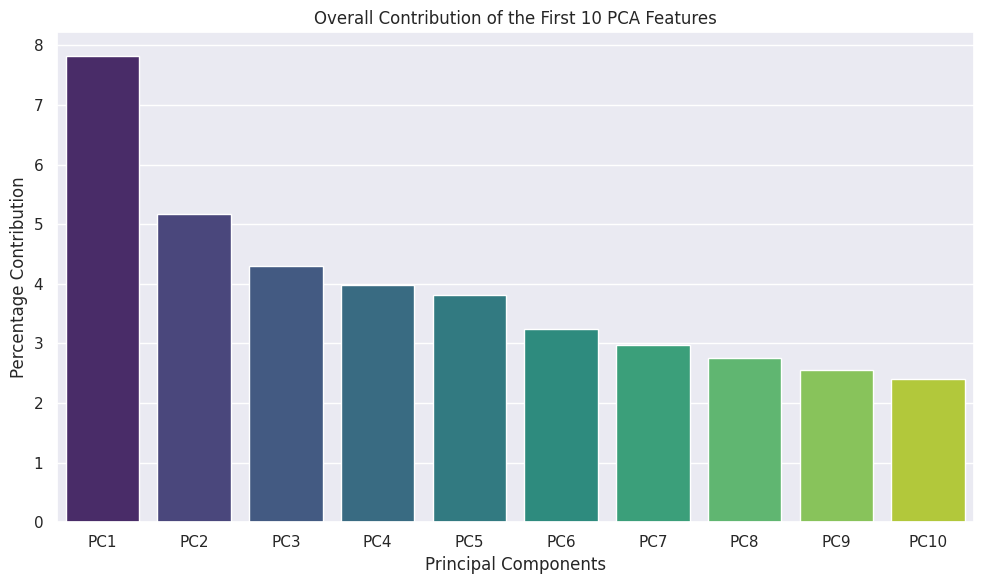

In [ ]:
explained_variance_ratio = pca_optimal.explained_variance_ratio_[:10]

# Calculate the percentage contribution of the first 10 components
percentage_contribution = explained_variance_ratio * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(1, 11), y=percentage_contribution, palette='viridis')
plt.xticks(np.arange(0, 10), [f'PC{i}' for i in range(1, 11)])
plt.xlabel('Principal Components')
plt.ylabel('Percentage Contribution')
plt.title('Overall Contribution of the First 10 PCA Features')
plt.tight_layout()
plt.show()

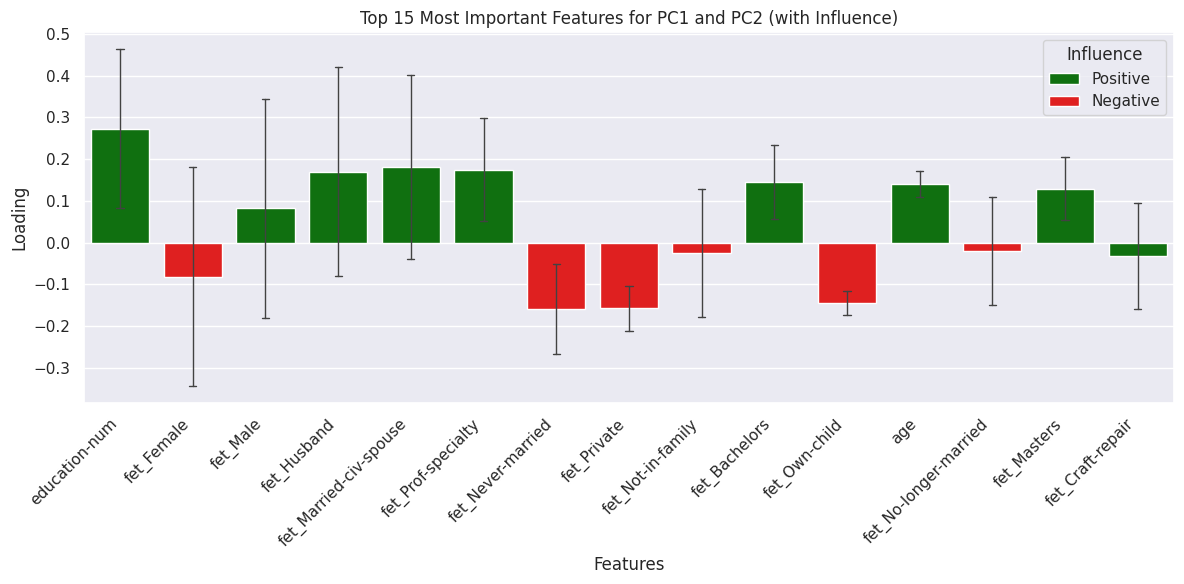

In [ ]:

# Get the absolute values of loadings for PC1 and PC2
loadings_abs = loadings_df[['PC1', 'PC2']].abs()

sorted_features = loadings_abs.sum(axis=1).sort_values(ascending=False)

# Select the top 15 features
top_15_features = sorted_features[:15].index

# Create a DataFrame for the top 15 features with loadings and influence
top_15_df = loadings_df.loc[top_15_features, ['PC1', 'PC2']]
top_15_df['Influence'] = np.where(top_15_df['PC1'] > 0, 'Positive', 'Negative')

# Melt the DataFrame to long format for plotting
top_15_melted = pd.melt(top_15_df.reset_index(), id_vars=['index', 'Influence'], value_vars=['PC1', 'PC2'], var_name='PC', value_name='Loading')

plt.figure(figsize=(12, 6))
sns.barplot(x='index', y='Loading', hue='Influence', data=top_15_melted,
            palette={'Positive': 'green', 'Negative': 'red'},
            errwidth=1,
            capsize=0.1)

plt.xticks(rotation=45, ha='right')

plt.xlabel('Features')
plt.ylabel('Loading')
plt.title('Top 15 Most Important Features for PC1 and PC2 (with Influence)')
plt.tight_layout()
plt.show()


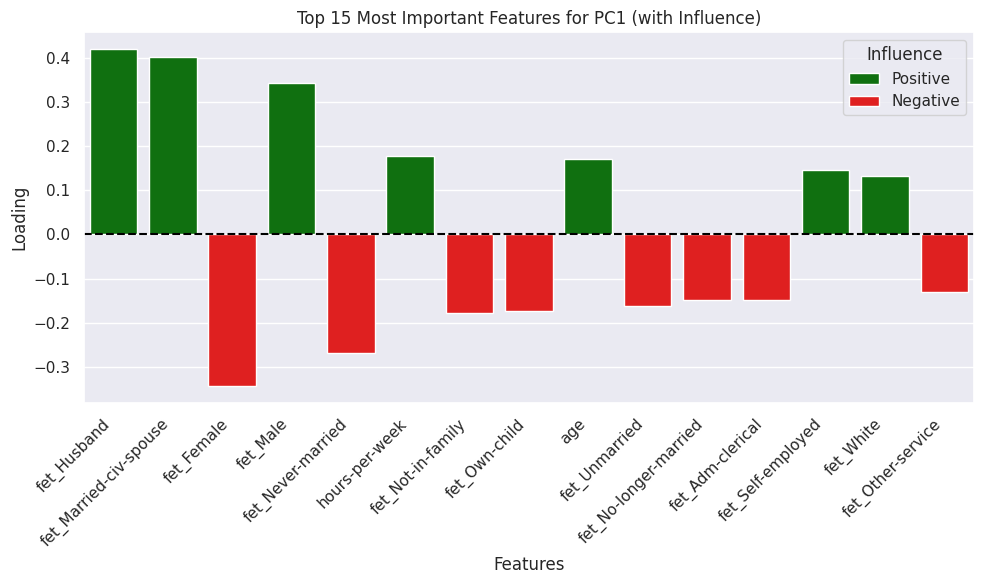

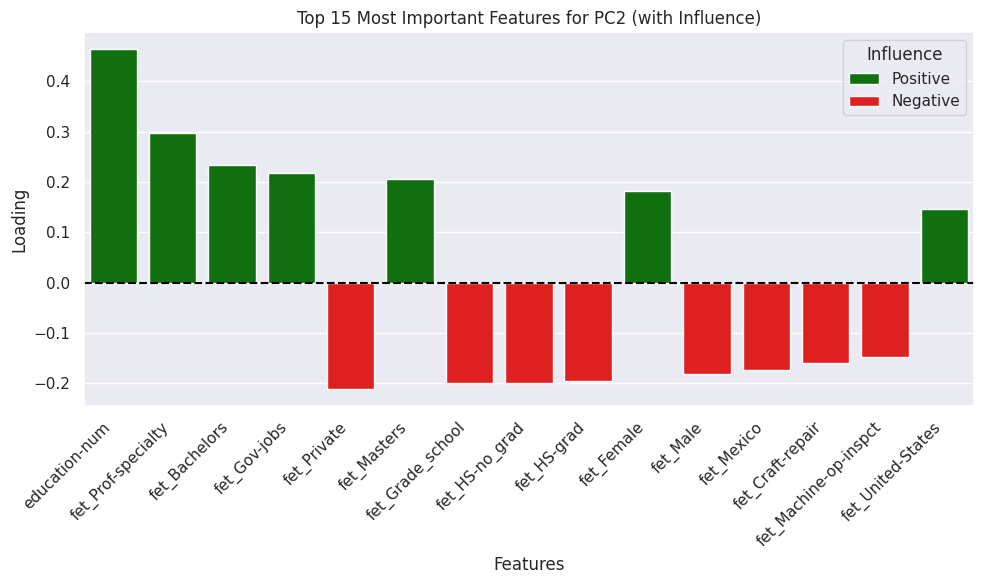

In [ ]:
# Get the absolute values of loadings for PC1 and PC2
loadings_abs = loadings_df[['PC1', 'PC2']].abs()

sorted_features_pc1 = loadings_abs['PC1'].sort_values(ascending=False)
sorted_features_pc2 = loadings_abs['PC2'].sort_values(ascending=False)

# Select the top 15 features for each component
top_15_features_pc1 = sorted_features_pc1[:15].index
top_15_features_pc2 = sorted_features_pc2[:15].index

# Create a DataFrame for the top 15 features with loadings and influence for PC1 and PC2
top_15_df_pc1 = loadings_df.loc[top_15_features_pc1, ['PC1']]
top_15_df_pc1['Influence'] = np.where(top_15_df_pc1['PC1'] > 0, 'Positive', 'Negative')


top_15_df_pc2 = loadings_df.loc[top_15_features_pc2, ['PC2']]
top_15_df_pc2['Influence'] = np.where(top_15_df_pc2['PC2'] > 0, 'Positive', 'Negative')

#Barplot for PC1 and PC2

plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_df_pc1.index, y=top_15_df_pc1['PC1'], hue=top_15_df_pc1['Influence'],
            palette={'Positive': 'green', 'Negative': 'red'})
plt.axhline(y=0, color='black', linestyle='--', label='y=0')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Loading')
plt.title('Top 15 Most Important Features for PC1 (with Influence)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_df_pc2.index, y=top_15_df_pc2['PC2'], hue=top_15_df_pc2['Influence'],
            palette={'Positive': 'green', 'Negative': 'red'})
plt.axhline(y=0, color='black', linestyle='--', label='y=0')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Loading')
plt.title('Top 15 Most Important Features for PC2 (with Influence)')
plt.tight_layout()
plt.show()

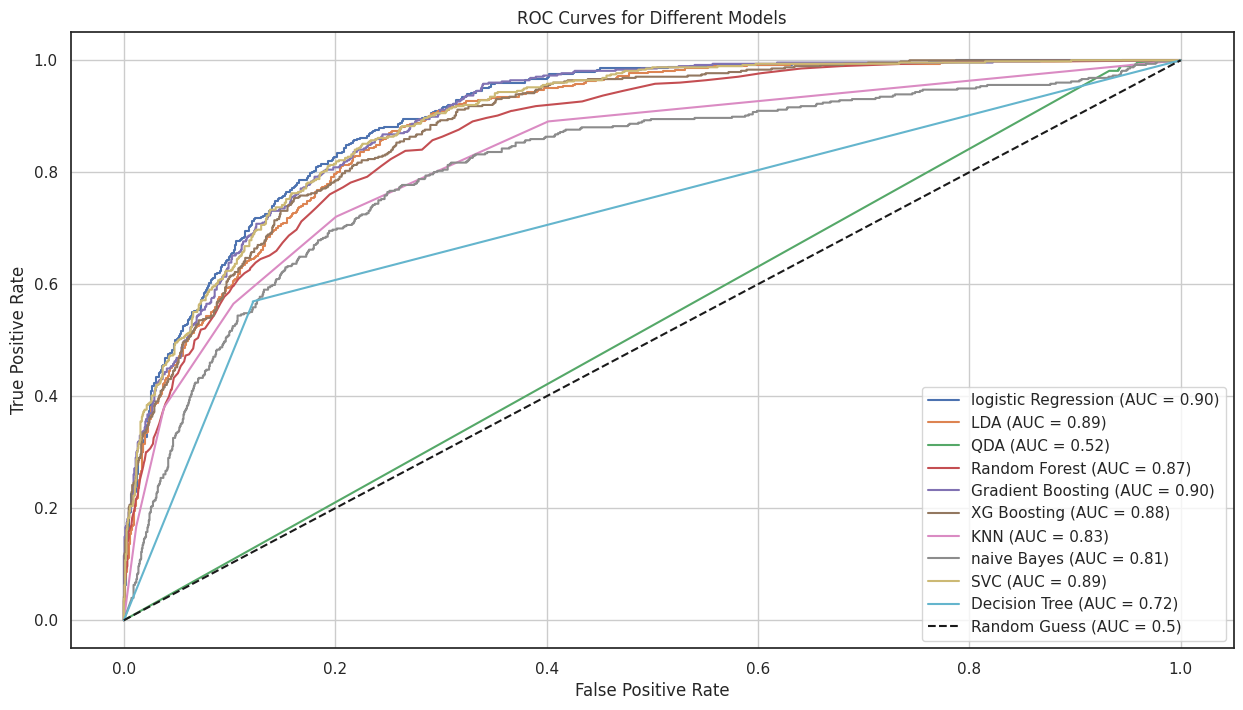

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

plt.figure(figsize=(15, 8))

model_dic={
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear',probability=True),
    "Decision Tree":DTC(criterion='entropy')
}
for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()

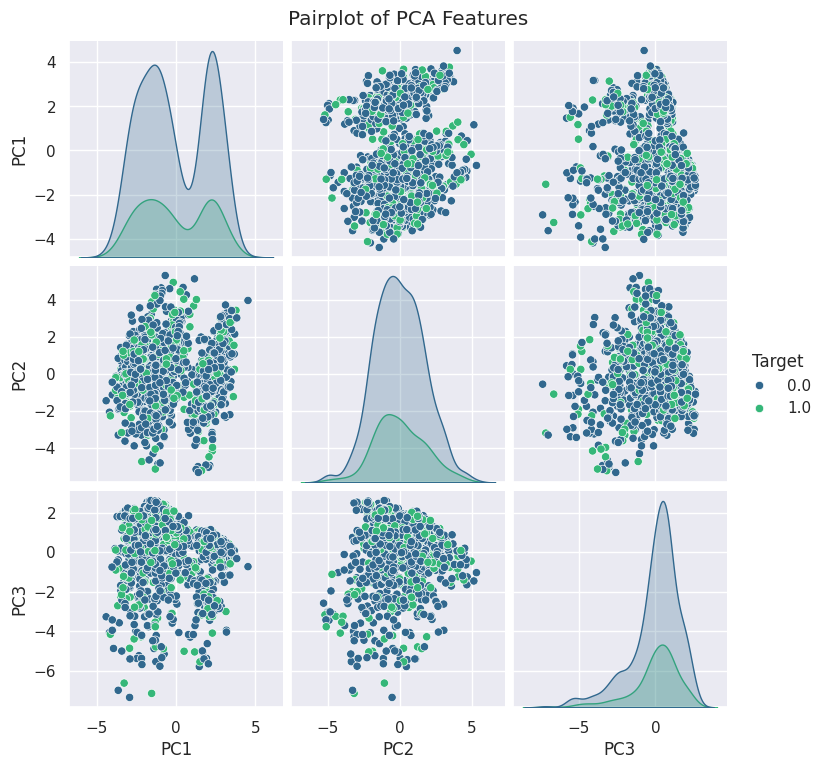

In [ ]:
df_pca = pd.DataFrame(X_train.iloc[:, :3].values, columns=['PC1', 'PC2', 'PC3'])  # Use .iloc for slicing and .values to get NumPy array
df_pca['Target'] = y_train

sns.pairplot(df_pca, hue='Target', diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot of PCA Features', y=1.02)
plt.show()

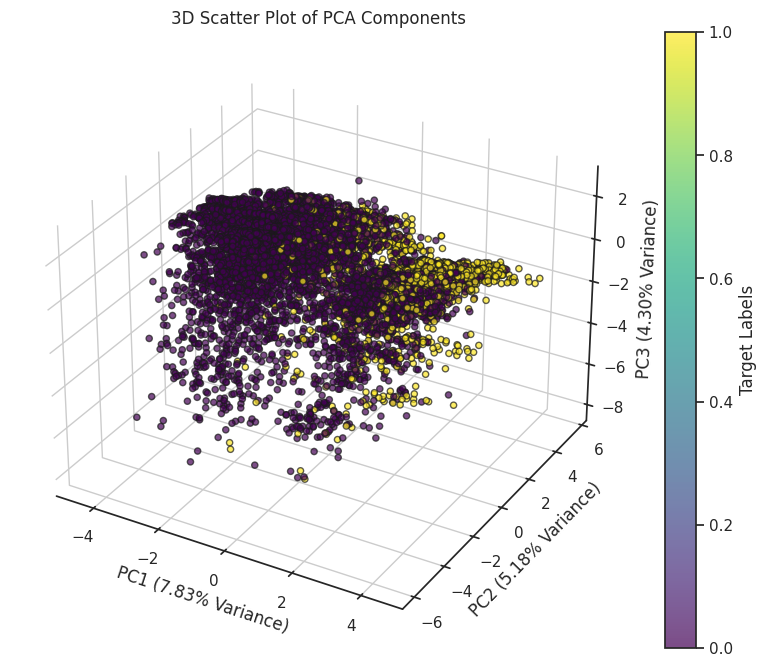

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
sns.set_theme(style="white")
# 3D Scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_train['PC1'], X_train['PC2'], X_train['PC3'],
                c=y_train, cmap='viridis', alpha=0.7, edgecolor='k')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} Variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} Variance)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.2%} Variance)")
ax.set_title('3D Scatter Plot of PCA Components')
fig.colorbar(sc, ax=ax, label='Target Labels')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.show()

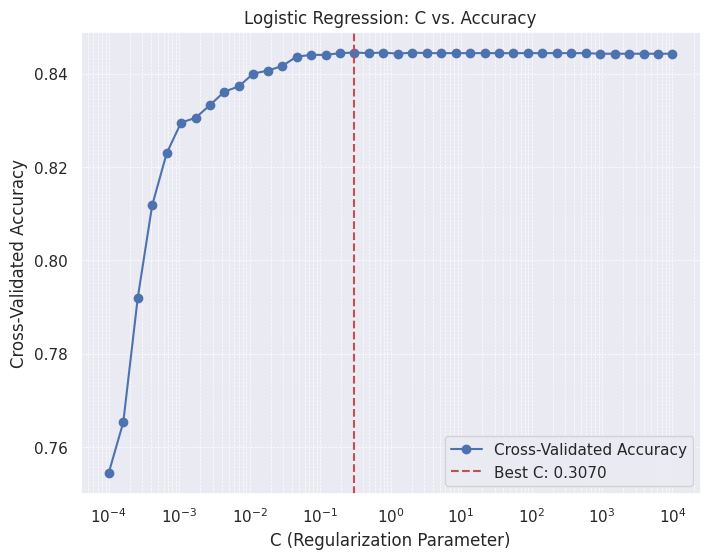

In [ ]:
C_values = np.logspace(-4, 4, 40)
accuracies = []

for C in C_values:
    model = LogisticRegression(C=C, random_state=42, max_iter=1000)
    scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=5)
    accuracies.append(scores.mean())

best_C = C_values[np.argmax(accuracies)]

plt.figure(figsize=(8, 6))
plt.plot(C_values, accuracies, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xscale('log')  # Log scale for C values
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Logistic Regression: C vs. Accuracy')
plt.axvline(best_C, color='r', linestyle='--', label=f'Best C: {best_C:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [ ]:
param_distributions = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [3000,3500,4000,5000],
    'l1_ratio': np.linspace(0, 1, 10)
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(C=best_C, random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

optimized_model = random_search.best_estimator_
test_accuracy = accuracy_score(y_test, optimized_model.predict(X_test))
print("Test Accuracy After Optimization:", test_accuracy)


Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 5000, 'l1_ratio': 0.5555555555555556}
Test Accuracy After Optimization: 0.8395


The optimal number of neighbors is 45 with an average training accuracy of 0.8246


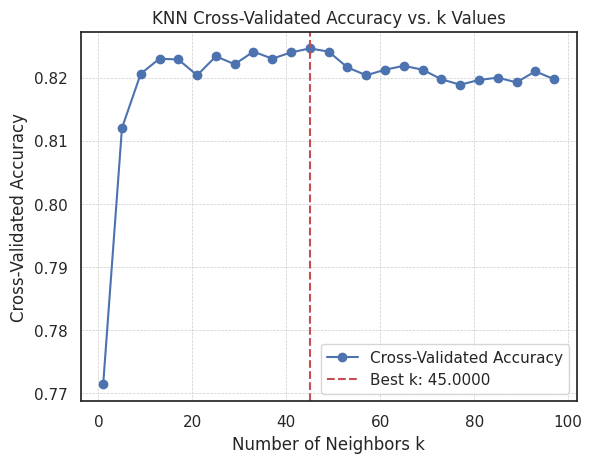

In [ ]:
k_values = range(1, 101, 4)
cv_scores = []

# Performing 10-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Finding the optimal k with the highest CV accuracy
optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of neighbors is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Cross-Validated Accuracy vs. k Values')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
param_dist = {
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
    'p': [1, 2, 3],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [2,5,7,10],
}

knn = KNeighborsClassifier(n_neighbors=45)

# Randomized search with 10 iterations
random_search = RandomizedSearchCV(knn, param_dist, n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=101)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'weights': 'distance', 'p': 3, 'metric': 'minkowski', 'leaf_size': 7, 'algorithm': 'auto'}
Best Accuracy: 0.8237501351340835


The optimal number of estimators is 200 with an average training accuracy of 0.8150


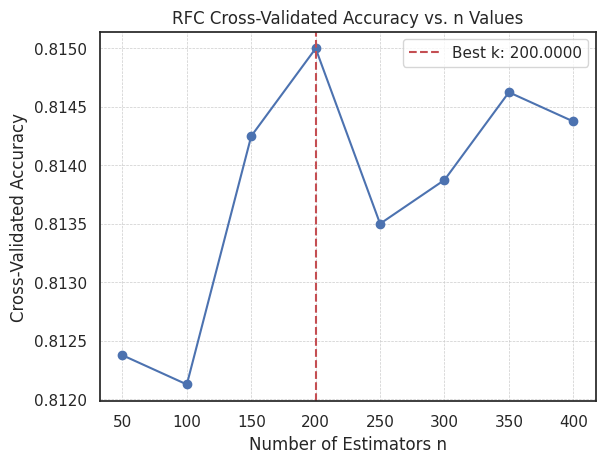

In [ ]:
k_values = [50,100,150,200,250,300,350,400]
cv_scores = []

for k in k_values:
    rfc = RandomForestClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(rfc, X_train, y_train, cv=3, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Estimators n')
plt.ylabel('Cross-Validated Accuracy')
plt.title('RFC Cross-Validated Accuracy vs. n Values')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
param_dist = {
    'max_depth': [10,20,30,50],
    'min_samples_split': [20,30,40,50],
    'min_samples_leaf': [1,2,3,4,5],
}

rf = RandomForestClassifier(n_estimators=200,random_state=101)

random_search = RandomizedSearchCV(rf, param_dist, n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=101)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'min_samples_split': 30, 'min_samples_leaf': 4, 'max_depth': 10}
Best Accuracy: 0.8251252445657347


In [ ]:
clf = DTC(criterion='entropy', random_state=101)

ccp_alphas = [0.005,0.007,0.01,0.015,0.02,0.03]

# Find the best ccp_alpha using cross-validation
best_score = 0
best_ccp_alpha = 0

for ccp_alpha in ccp_alphas:
    clf = DTC(criterion='entropy', random_state=101, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_ccp_alpha = ccp_alpha

# Train the final pruned tree with the best ccp_alpha
pruned_tree = DTC(criterion='entropy', random_state=101, ccp_alpha=best_ccp_alpha)
pruned_tree.fit(X_train, y_train)

print("Best ccp_alpha:", best_ccp_alpha)

Best ccp_alpha: 0.007


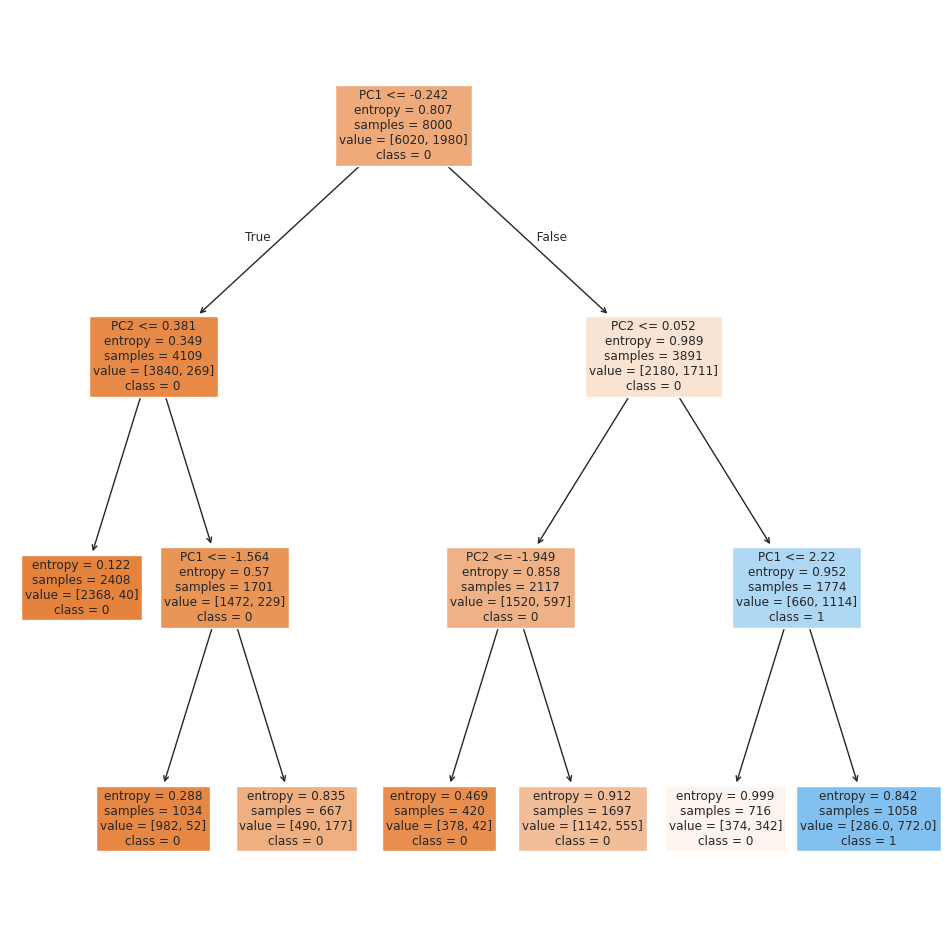

In [ ]:
feature_names=list(X_train.columns)
fig, ax=subplots(figsize=(12,12))
plot_tree(pruned_tree,feature_names=feature_names,class_names=['0','1'],filled=True,ax=ax)
plt.show()

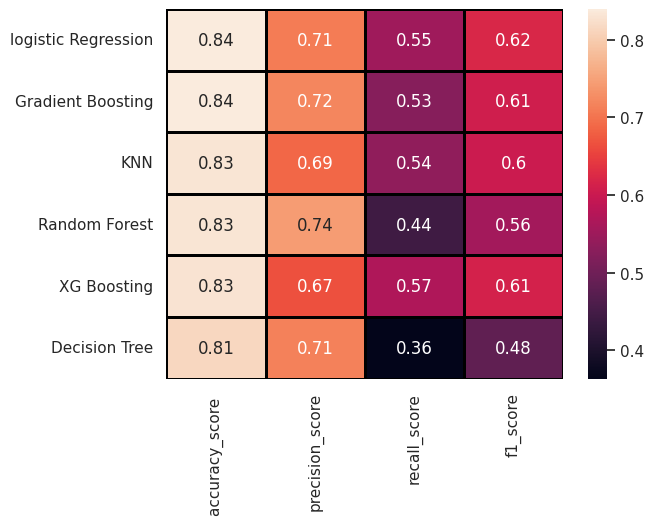

In [ ]:
model_dic={
    'logistic Regression':LogisticRegression(C=0.3),
    'Random Forest':RandomForestClassifier(n_estimators=200,min_samples_split=30,min_samples_leaf=4,max_depth=10),
    "Decision Tree":pruned_tree,
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(n_neighbors=45,weights='distance',metric='minkowski',leaf_size=7,algorithm='auto',p=3),

}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)  # Convert to Numpy array for xGboost
        y_pred = model.predict(X_test.to_numpy())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1)
plt.show()

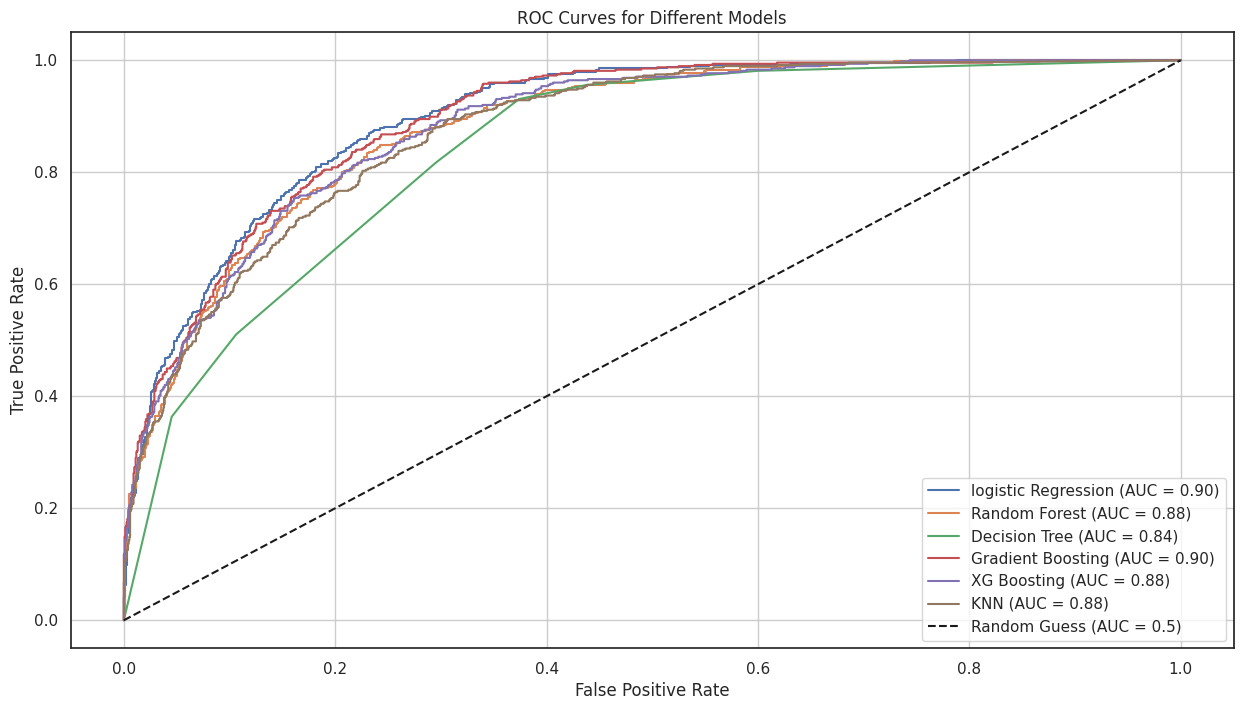

In [ ]:
plt.figure(figsize=(15, 8))

model_dic={
    'logistic Regression':LogisticRegression(C=0.3),
    'Random Forest':RandomForestClassifier(n_estimators=200,min_samples_split=30,min_samples_leaf=4,max_depth=10),
    "Decision Tree":pruned_tree,
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(n_neighbors=45,weights='distance',metric='minkowski',leaf_size=7,algorithm='auto',p=3),

}
for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()